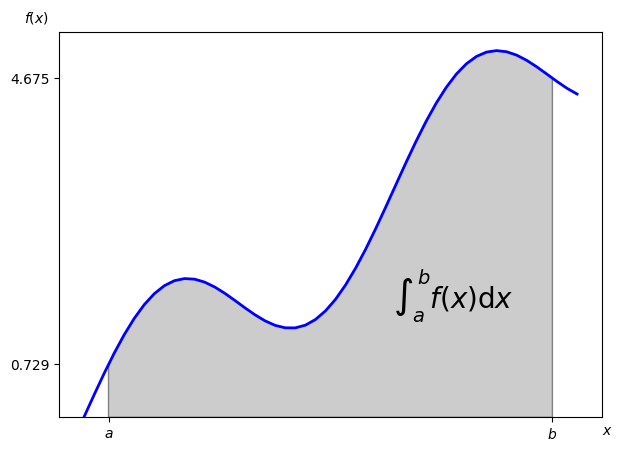

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as sci
def f(x):
    return np.sin(x) + 0.5 * x
a = 0.5
b = 9.5
x = np.linspace(0,10)
y = f(x)

from matplotlib.patches import Polygon
fig, ax = plt.subplots(figsize=(7,5))
plt.plot(x,y, 'b', linewidth=2)
plt.ylim(ymin=0)
Ix = np.linspace(a,b)
Iy = f(Ix)
verts = [(a,0)]+list(zip(Ix,Iy))+[(b,0)]
poly = Polygon(verts, facecolor='0.8', edgecolor='0.5')
ax.add_patch(poly)
plt.text(0.75 * (a + b), 1.5, r"$\int_a^b f(x)\mathrm{d}x$", horizontalalignment='center', fontsize=20)
plt.figtext(0.9, 0.075, '$x$')
plt.figtext(0.075, 0.9, '$f(x)$')
ax.set_xticks((a,b))
ax.set_xticklabels(('$a$','$b$'))
ax.set_yticks([f(a),f(b)])
ax.set_yticks([f(a),f(b)])



# 积分

## 蒙特卡洛模拟（MCS）
$$  S_T = S_0 \exp \left( \left( r - \frac{1}{2} \sigma^2 \right) T + \sigma \sqrt{T} \cdot \xi \right) $$

numpy.exp 是 NumPy 库中的指数函数，用于计算数组中每个元素的自然指数
即 $$ e^x$$

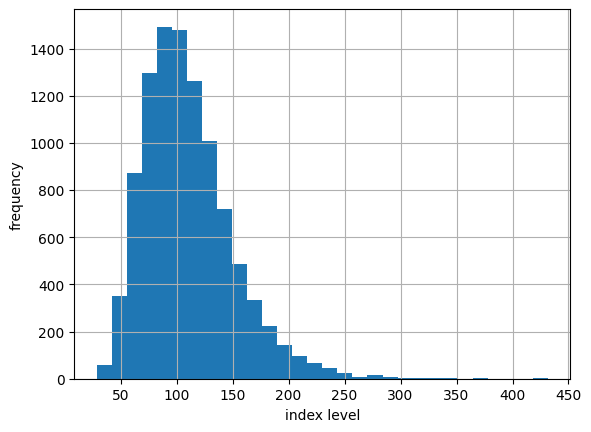

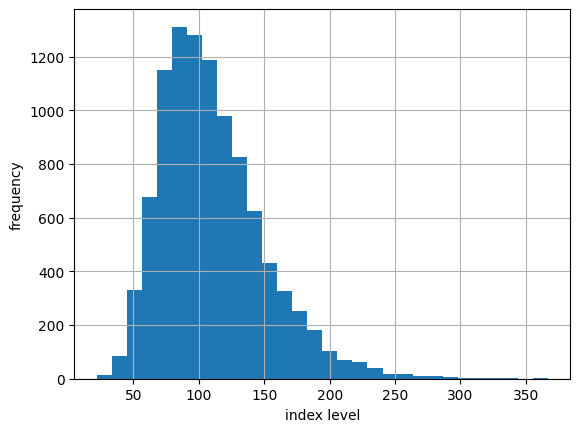

     statistic             ST1             ST2
           min        28.87852        22.17851
           max       431.57521       366.77278
          mean       110.37640       110.40793
           std        40.05837        39.70750
          skew         1.12817         1.05335
      kurtosis         2.51347         1.85901


In [10]:
import numpy.random as npr
import numpy as np
S0 = 100
r = 0.05
sigma = 0.25
T = 2.0
I = 10000
ST1 = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * npr.standard_normal(I))
plt.hist(ST1, bins=30)
plt.grid(True)
plt.xlabel('index level')
plt.ylabel('frequency')
plt.show()

ST2 = S0 * npr.lognormal((r - 0.5 * sigma ** 2) * T, sigma * np.sqrt(T), I)
plt.hist(ST2, bins=30)
plt.grid(True)
plt.xlabel('index level')
plt.ylabel('frequency')
plt.show()

import scipy.stats as scs
def print_statistics(ST1, ST2):
    stat1 = scs.describe(ST1)
    stat2 = scs.describe(ST2)
    print('%14s %15s %15s' % ('statistic', 'ST1', 'ST2'))
    print('%14s %15.5f %15.5f' % ('min', stat1[1][0], stat2[1][0]))
    print('%14s %15.5f %15.5f' % ('max', stat1[1][1], stat2[1][1]))
    print('%14s %15.5f %15.5f' % ('mean', stat1[2], stat2[2]))
    print('%14s %15.5f %15.5f' % ('std', np.sqrt(stat1[3]), np.sqrt(stat2[3])))
    print('%14s %15.5f %15.5f' % ('skew', stat1[4], stat2[4]))
    print('%14s %15.5f %15.5f' % ('kurtosis', stat1[5], stat2[5]))

print_statistics(ST1, ST2)

